**Achieved Training Accuracy of 0.7185 (71.85%) after 200 epochs and Evaluation Accuracy of 0.678 (67.8 %)**

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Conv2D , MaxPool2D , Dense , Rescaling , Flatten , Dropout , RandomFlip , RandomZoom , RandomRotation
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
(X_train , Y_train) , (X_test , Y_test) = cifar10.load_data()

In [ ]:
print(X_train.shape)
print(Y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [ ]:
Y_train = Y_train.reshape(-1)
print(Y_train.shape)

Y_test = Y_test.reshape(-1)
print(Y_test.shape)

(50000,)
(10000,)


In [ ]:
classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [ ]:
def plot_sample(X , Y , index) :
  plt.figure(figsize = (15,2))
  plt.imshow(X[index])
  plt.xlabel(classes[Y[index]])

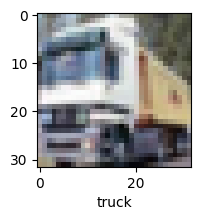

In [ ]:
plot_sample(X_train,Y_train , 1)

In [ ]:
normalizer = Rescaling(1/255)

X_train = normalizer(X_train)
X_test = normalizer(X_test)

**When designing the convolutional layers of a CNN, a good standard practice is to start with a modest number of filters in the early layers and progressively double them as you go deeper into the network (e.g., 32 → 64 → 128 → 256).**

In [ ]:
#Data Augmentation
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomZoom(0.2),
    RandomRotation(0.2)
])

In [ ]:
#Sequential needs layers to e passed into as a List
#filters means how many features should be extracted by the kernel when it strides over the image
cnn_model = Sequential([
    data_augmentation,
    Conv2D(filters = 64 , kernel_size = (3,3) , activation = 'relu' , input_shape=(32,32,3)),
    MaxPool2D((2,2)),

    Conv2D(filters = 128 , kernel_size = (3,3) , activation = 'relu'),
    MaxPool2D((2,2)),

    Conv2D(filters = 256 , kernel_size = (3,3) , activation = 'relu'),
    MaxPool2D((2,2)),

    Flatten(),
    Dropout(0.3),                        # <- randomly drops 50% of neurons during training
    Dense(256 , activation = 'relu'),
    Dense(128 , activation = 'relu'),
    Dense(10 , activation = 'softmax')
])



In [ ]:
cnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

If instead your labels look like: [0,0,0,0,0,0,1,0,0,0]  which is 'one-hot encoded'

then use: loss='categorical_crossentropy'

CIFAR-10 normally gives labels like:

0
1
6
3
9
...

Then use:
loss='sparse_categorical_crossentropy'

In [ ]:
cnn_model.compile(
    optimizer = 'Adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

**verbose in model.fit() controls how much information Keras prints in the output while training.**

verbose=1 — progress bar

This is the default in many Keras setups.
You'll see something like:

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
loss: 1.42 - accuracy: 0.48

It shows a progress bar as batches are processed.



verbose=0 — completely silent
cnn_model.fit(
    X_train,
    Y_train,
    epochs=10,
    verbose=0
)

Nothing is printed while training.
Useful when you don't want your notebook flooded with output.



verbose=2 — one line per epoch
cnn_model.fit(
    X_train,
    Y_train,
    epochs=10,
    verbose=2
)

Instead of a live progress bar, you get something like:

Epoch 1/10
loss: 1.42 - accuracy: 0.48
Epoch 2/10
loss: 1.18 - accuracy: 0.57
Epoch 3/10
loss: 1.02 - accuracy: 0.64




In [ ]:
history = cnn_model.fit(X_train,Y_train,epochs=100,validation_split=0.1,verbose=1)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6928 - loss: 0.8879 - val_accuracy: 0.7088 - val_loss: 0.8592
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6950 - loss: 0.8826 - val_accuracy: 0.7110 - val_loss: 0.8371
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6919 - loss: 0.8908 - val_accuracy: 0.6846 - val_loss: 0.8994
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6982 - loss: 0.8798 - val_accuracy: 0.7228 - val_loss: 0.8229
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6944 - loss: 0.8818 - val_accuracy: 0.7120 - val_loss: 0.8528
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6874 - loss: 0.8971 - val_accuracy: 0.7152 - val_loss: 0.8443
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6921 - loss: 0.8835 - val_accuracy: 0.7232 - val_loss: 0.8189
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6918 -

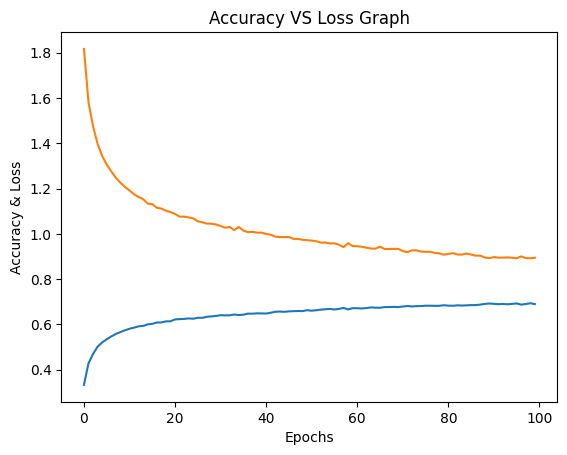

In [ ]:
accuracy_metric = history.history['accuracy']
loss_metric = history.history['loss']

plt.plot(accuracy_metric)
plt.plot(loss_metric)

plt.xlabel('Epochs')
plt.ylabel('Accuracy & Loss')
plt.title('Accuracy VS Loss Graph')
plt.show()

In [ ]:
cnn_model.evaluate(X_test , Y_test) #"How good is my model?"

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6750 - loss: 0.9648


[0.9648230671882629, 0.675000011920929]

In [ ]:
Y_pred = cnn_model.predict(X_test) #"What does my model predict for each individual image?"
print(Y_pred[:5])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[1.47279231e-02 1.99357510e-01 4.65996340e-02 2.85532355e-01
  4.31965757e-03 2.11006850e-01 3.33393924e-02 2.82136034e-02
  5.33143952e-02 1.23588696e-01]
 [9.99556202e-03 4.55175400e-01 3.36236517e-05 4.67626705e-06
  5.74818500e-07 1.91188360e-06 5.15443617e-06 5.96371219e-09
  5.34322858e-01 4.60291165e-04]
 [4.55119014e-02 8.06233943e-01 5.86689450e-04 7.46706559e-04
  1.98810274e-04 3.03440698e-04 7.26707804e-04 1.22464393e-04
  7.83602297e-02 6.72090128e-02]
 [9.21811283e-01 1.68097951e-02 2.83458680e-02 1.08067004e-03
  8.72254546e-04 2.62960937e-04 1.72442000e-04 1.06948894e-03
  1.37077672e-02 1.58675835e-02]
 [9.93054812e-08 3.56876353e-06 1.13180235e-04 2.75654107e-04
  1.34564738e-03 4.68879671e-06 9.98242736e-01 7.75895881e-09
  4.23156230e-08 1.44642490e-05]]


**For a 2D NumPy array:**

**axis=0 means ↓ down**

**axis=1 means → across**

In [ ]:
import numpy as np
Y_classes = np.argmax(Y_pred , axis = 1)

In [ ]:
print(Y_classes[0:17])
print(Y_test[0:17])

[3 8 1 0 6 6 1 6 3 1 0 9 3 7 9 8 5]
[3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5]


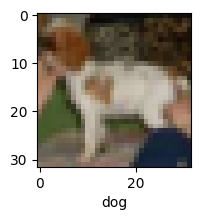

In [ ]:
plot_sample(X_test, Y_test, 12)

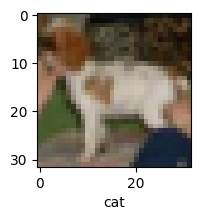

In [ ]:
plot_sample(X_test, Y_classes, 12)

**Save this Model**

In [ ]:
cnn_model.save('cifar10_model.keras') #temporarily in colab's runtime

In [ ]:
from google.colab import drive #save it in drive directly
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define path inside Google Drive
save_dir = '/content/drive/MyDrive/Shreejeet_Aaryan'
os.makedirs(save_dir, exist_ok=True)

# 3. Save model
cnn_model.save(f'{save_dir}/cifar10_model.keras')

ValueError: mount failed

**To load the model**

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# from tensorflow.keras.models import load_model

# cnn_model = load_model('/content/drive/MyDrive/Shreejeet_Aaryan/cifar10_model.keras')